In [9]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import f1_score, make_scorer, accuracy_score
import pandas as pd
import numpy as np
import csv
import pickle 

In [3]:
class TextProcessing:
    def __init__(self, review):
        self.review=review
    def processing(self):
        with open(self.review, 'r', newline='') as f:
            reader = csv.DictReader(f)
            with open('data.csv', 'w', newline='') as out_f:
                fieldnames = ['Country', 'Review Date', 'Review Title', 'Review Text', 'Rating']  
                writer = csv.DictWriter(out_f, fieldnames=fieldnames)
                writer.writeheader()
                for row in reader:
                    writer.writerow({
                        'Country': row['Country'],
                        'Review Date': row['Review Date'],
                        'Review Title': row['Review Title'],
                        'Review Text' : row['Review Text'],
                        'Rating': row['Rating']
                })
        df = pd.read_csv('data.csv', parse_dates=['Review Date'],on_bad_lines='skip')
        df.dropna(inplace=True)
        df.drop_duplicates(inplace=True)
        #df['Rating'].str.split()
        df['Num_Rating']=df['Rating'].apply(lambda x:'POSITIVE' if int(x[6])>=4 else 'NEUTRAL' if int(x[6])==3 else 'NEGATIVE') #if int(x)<3)
        df['Review Date']= df['Review Date'].dt.year
        return df
    def Graph(self):
        df=self.processing()
        fg=df[df['Review Date']>2015]
        df.head()
        df['Num_Rating'].value_counts().plot(kind='bar', color='g')
        df[['Review Date','Num_Rating']] .value_counts()

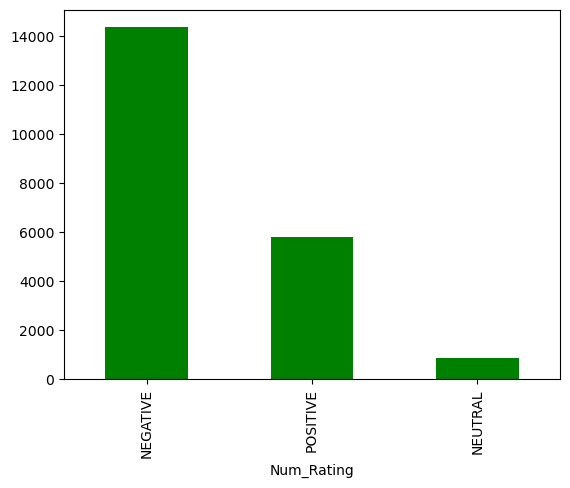

In [4]:
data_ = TextProcessing('Amazon_Reviews.csv')
data_.Graph()

In [35]:
data=data_.processing()
data['num_rate']=data['Num_Rating'].map({'POSITIVE':1.0, 'NEUTRAL':0.0,'NEGATIVE':0.0})
X,y= data['Review Text'].values ,data['num_rate'].values
Xtrain, Xtest,ytrain,ytest = train_test_split(X, y, test_size=0.1,random_state=42, shuffle=True)
ytrain[:100].dtype

dtype('float64')

In [86]:
#Model train
pipe=Pipeline([('scalar', CountVectorizer()), ('clf', LogisticRegression())])

param_grid= [
            {'clf': [KNeighborsClassifier()]},
            {'clf': [SVC()]},
            {'clf': [LogisticRegression(max_iter=1000)]}
            ]
grid= GridSearchCV(estimator=pipe, 
                   param_grid=param_grid,           
                   cv=5,
                   scoring= make_scorer(f1_score, average='macro'),
                   refit = True
                      )
grid.fit(Xtrain, ytrain)

#voting= VotingClassifier(estimators=[('knn' , [CountVectorizer(), KNeighborsClassifier()]), 
                                    #('mnb', [CountVectorizer(), MultinomialNB()]), 
                                     #('lgt3', [CountVectorizer(),LogisticRegression()])],
                                      #voting='soft')
#voting.fit(Xtrain,ytrain)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'clf': [KNeighborsClassifier()]}, {'clf': [SVC()]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(f...average=macro)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the sc

In [87]:
y_pred=grid.predict(Xtest)
score=f1_score(y_pred, ytest)
score

0.8478073946689596

In [50]:
y=lambda x: 'Postive Sentiment' if grid.predict(x)==1 else 'Negative Sentiment'

In [85]:
y(['got value for my money'])

'Postive Sentiment'

In [ ]:
pipe=[Pipeline([('scaler', CountVectorizer()),
      ('model', LogisticRegression())]),
      Pipeline([('scaler', CountVectorizer()),
      ('model', SVC())]),
      Pipeline([('scaler', CountVectorizer()),
      ('model', DecisionTreeClassifier())]),
      Pipeline([('scaler', CountVectorizer()),
      ('model', KNeighborsClassifier())])
      ]
param_grid= [{'model__class_weight': [{0:1, 1:v} for v in range(10)]},
             {'model__C': [0.3,0.4, 0.6]},
             {'model__max_depth': [1,2,3]},
             {'model__n_neighbors': [3,4,5]}
            ]

for i in zip(pipe, param_grid):
  mod=GridSearchCV(estimator=i[0], param_grid=i[1], cv=5)
  mod.fit(X, y)
  print(mod.best_params_)
  print(i[0], i[1])

In [20]:
voting = VotingClassifier(
    estimators=[
        ('lr', Pipeline([
            ('scaler', CountVectorizer()),
            ('lr', LogisticRegression())
        ])),

        ('svc', Pipeline([
            ('scaler', CountVectorizer()),
            ('svc', SVC())
        ])),

        ('dt', Pipeline([
            ('scaler', CountVectorizer()),
            ('dt', DecisionTreeClassifier())
        ])),

        ('knn', Pipeline([
            ('scaler', CountVectorizer()),
            ('knn', KNeighborsClassifier())
        ]))
    ],
    voting='soft')
#voting.fit(Xtrain, ytrain.ravel())
#y_pred = voting.predict(Xtest)
#print(confusion_matrix(ytest.ravel(), y_pred))
#print(classification_report(ytest.ravel(), y_pred))

### Model Deployment

In [66]:
with open('model.pkl', 'wb') as f:
    pickle.dump(grid, f)

In [84]:
with open('model.pkl', 'rb') as f:
    model=pickle.load(f)
    y=lambda x: 'Postive Sentiment' if model.predict(x)==1 else 'Negative Sentiment'
    print(y(['not good value for my money']))

Negative Sentiment
